In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/content/gurgaon_properties_cleaned_v2.csv")
df.shape

(3784, 23)

In [6]:
df.sample()

,society,price,sector,price_per_sqft,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,area,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3553,paras dews,1.25,sector 106,11061.0,Super Built up area 1760(163.51 sq.m.)Built Up...,3,4,3+,7,South-East,Relatively New,1130.0,flat,1760.0,1186.0,1130.0,1,1,0,0,0,0,167


In [7]:
df.duplicated().sum()

np.int64(125)

In [8]:
df.drop_duplicates(inplace=True)

<Axes: xlabel='property_type'>

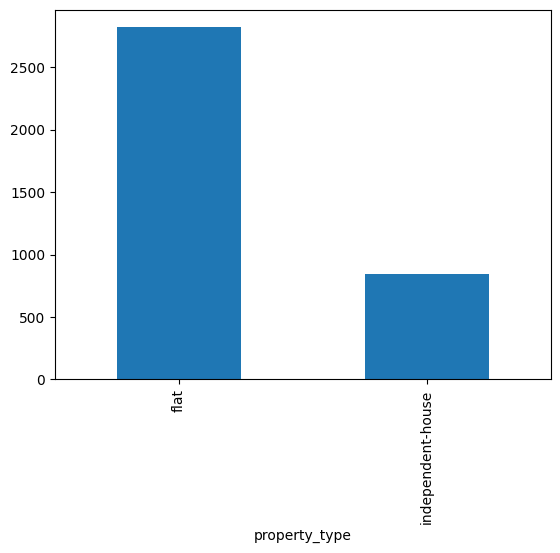

In [9]:
df['property_type'].value_counts().plot(kind='bar')

In [10]:
df['society'].value_counts()

,count
society,
independent,477
tulip violet,75
ss the leaf,73
shapoorji pallonji joyville gurugram,42
dlf new town heights,41
...,...
espire south,1
"godrej 101, sector 79",1
la lagune,1


In [11]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(75)

,proportion
society,
tulip violet,0.023570
ss the leaf,0.046512
shapoorji pallonji joyville gurugram,0.059711
dlf new town heights,0.072596
signature global park,0.083595
...,...
umang winter hills,0.490572
indiabulls enigma,0.494657
the close north,0.498743


The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies


Around 13% properties comes under independent tag.





In [12]:
society_counts=df['society'].value_counts()
freq={
    'Very High':(society_counts>100).sum(),
    "high":((society_counts>=50) & (society_counts<=100)).sum(),
    "avg":((society_counts>=10) & (society_counts<50)).sum(),
    "Low":((society_counts>1) & (society_counts<10)).sum(),
    "very Low":(society_counts==1).sum()
}

freq

{'Very High': np.int64(1),
 'high': np.int64(2),
 'avg': np.int64(92),
 'Low': np.int64(273),
 'very Low': np.int64(304)}

Very High (>100): Only 1 society has more than 100 listings.

High (50-100): 2 societies have between 50 to 100 listings.

Average (10-49): 92 societies fall in this range with 10 to 49 listings each.

Low (2-9): 273 societies have between 2 to 9 listings.

Very Low (1): A significant number, 308 societies, have only 1 listing.

<Axes: xlabel='society'>

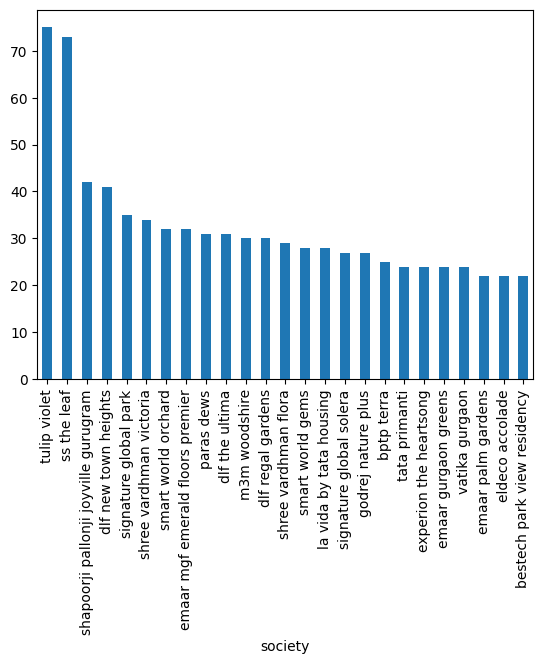

In [13]:
df[df['society']!='independent']['society'].value_counts().head(25).plot(kind='bar')

In [14]:
df['society'].isnull().sum()

np.int64(0)

In [15]:
df['sector'].value_counts().shape


(115,)

<Axes: xlabel='sector'>

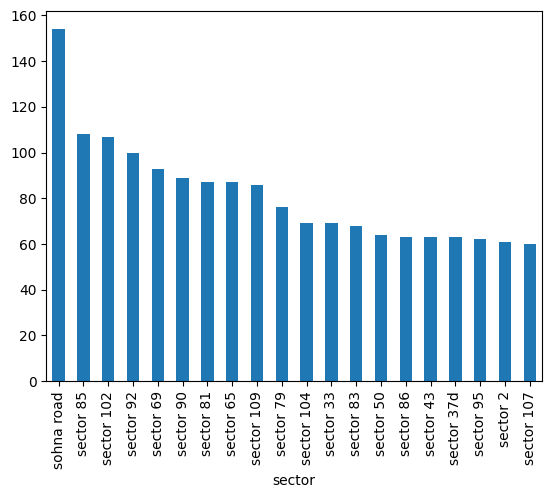

In [16]:
df['sector'].value_counts().head(20).plot(kind='bar')


In [17]:

# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(3),
 'High (50-100)': np.int64(24),
 'Average (10-49)': np.int64(64),
 'Low (2-9)': np.int64(23),
 'Very Low (1)': np.int64(1)}

There are a total of 115 unique sectors in the dataset.

Frequency distribution of sectors:

Very High (>100): 3 sectors have more than 100 listings.

High (50-100): 25 sectors have between 50 to 100 listings.

Average (10-49): A majority, 60 sectors, fall in this range with 10 to 49 listings each.

Low (2-9): 16 sectors have between 2 to 9 listings.

Very Low (1): Interestingly, there are no sectors with only 1 listing.

In [18]:
df['price'].isnull().sum()

np.int64(17)

In [19]:
df['price'].describe()

,price
count,3642.000000
mean,2.520258
std,2.970983
min,0.070000
25%,0.950000
50%,1.515000
75%,2.700000
max,31.500000


<Axes: xlabel='price', ylabel='Count'>

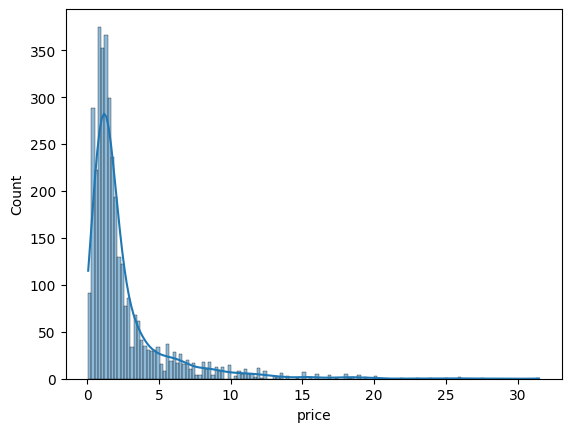

In [20]:
sns.histplot(df["price"],kde=True)  ## there is many outliers...

<Axes: xlabel='price'>

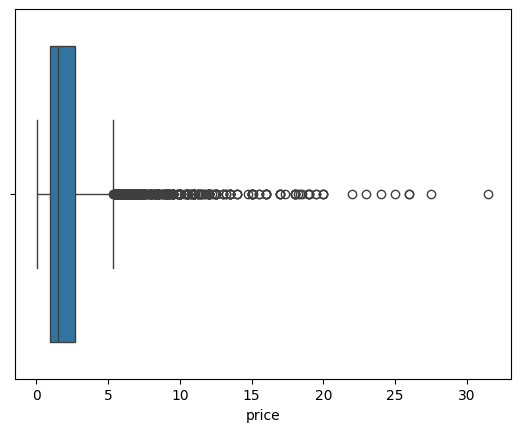

In [21]:
sns.boxplot(x=df['price'])

# Visualizations:
Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.

Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.

> 0 → right skewed

< 0 → left skewed

≈ 0 → symmetric

In [22]:

skewness=df['price'].skew()
krtosis=df['price'].kurt()

print(skewness,krtosis)

3.314084176125422 15.241573067942884


Skewness: The price distribution has a skewness of approximately 3.31, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

Kurtosis: The kurtosis value is approximately 15.24
. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [23]:
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

,price
0.01,0.2500
0.05,0.3700
0.95,8.4995
0.99,15.3360


In [24]:
from numpy._core.defchararray import lower
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1
print("IQR:",IQR)

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR

print(lower_bound, upper_bound)


IQR: 1.7500000000000002
-1.6750000000000005 5.325000000000001


In [25]:
outliers=df[(df['price']<lower_bound) | (df['price']>upper_bound)]
outliers.shape

(419, 23)

In [26]:
outliers['price'].describe()

,price
count,419.000000
mean,9.227041
std,4.092818
min,5.350000
25%,6.400000
50%,8.000000
75%,10.750000
max,31.500000


Based on the IQR method, there are 419 properties considered as outliers.
These outliers have an average price of approximately 9.22 crores.
The range for these outliers is from 5.36 crores to 31.5 crores.

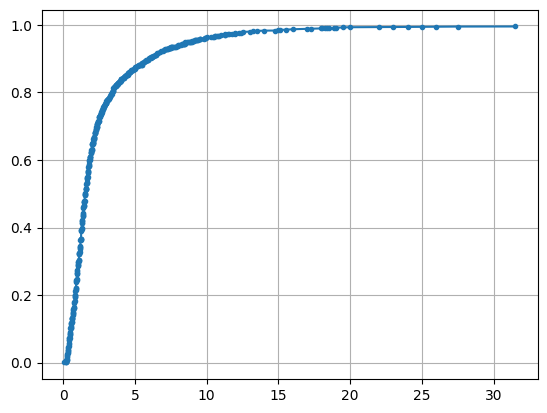

In [27]:
ecdf=df['price'].value_counts().sort_index().cumsum()/len(df['price'])
plt.plot(ecdf.index,ecdf,marker='.')
plt.grid()
plt.show()

ECDF = Empirical Cumulative Distribution Function

In simple words:

For any price x, ECDF tells you:
“What fraction of data points are ≤ x ?”

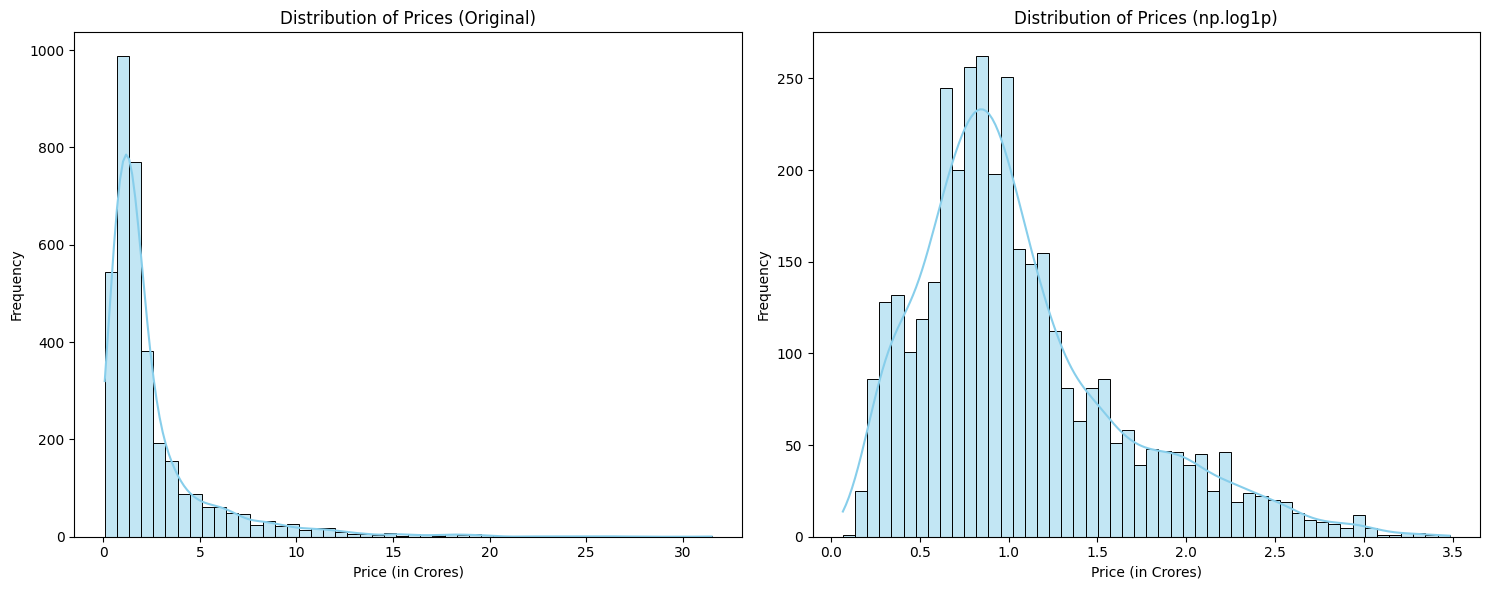

In [28]:
plt.figure(figsize=(15,6))

# normal kde
plt.subplot(1,2,1)
sns.histplot(df['price'],kde=True,bins=50,color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# apply np.log1p on price data
plt.subplot(1,2,2)
sns.histplot(np.log1p(df['price']),kde=True,bins=50,color='skyblue')
plt.title('Distribution of Prices (np.log1p)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


np.log1p(x): This function computes the natural logarithm of 1+x. It's designed to provide more accurate results for values of x that are very close to zero.

Using np.log1p helps in transforming the price column while ensuring that any value (including zero, if present) is handled appropriately. When we need to reverse the transformation, we can use np.expm1 which computes e^x-1

In [29]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.083573510049411 1.0105617327369707


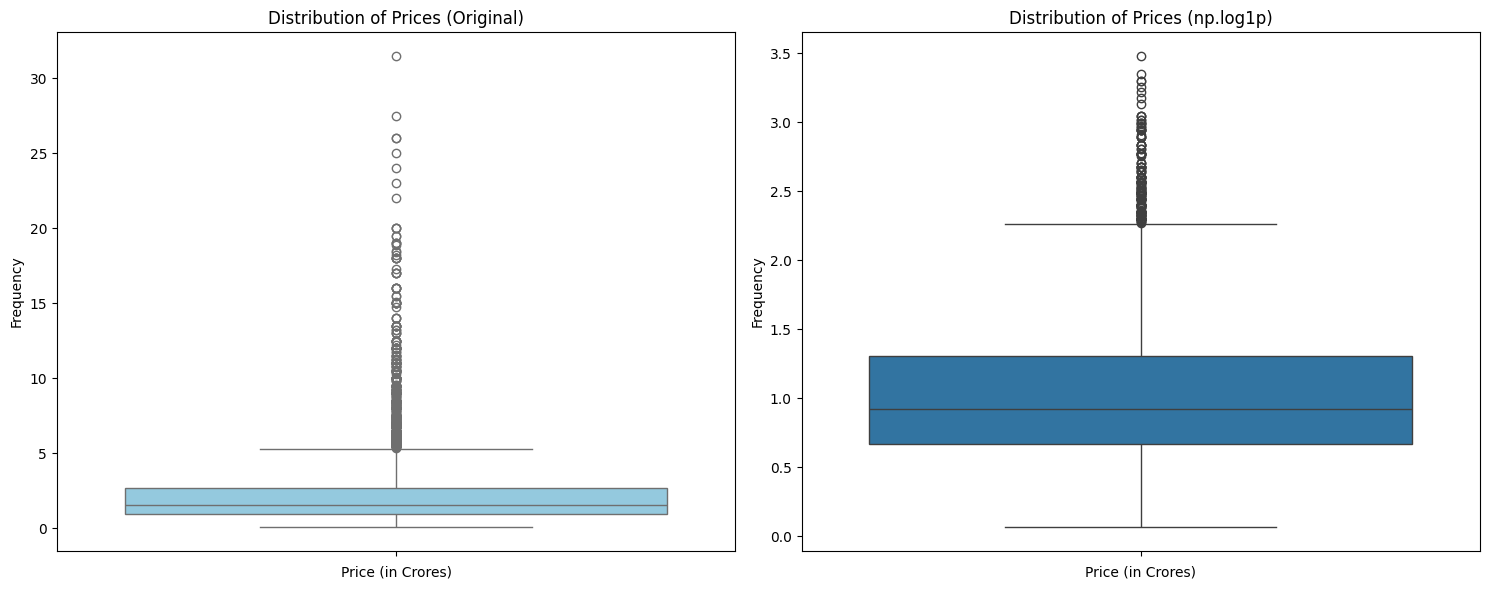

In [30]:
plt.figure(figsize=(15,6))

# normal kde
plt.subplot(1,2,1)
sns.boxplot(df['price'],color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# apply np.log1p on price data
plt.subplot(1,2,2)
sns.boxplot(np.log1p(df['price']))
plt.title('Distribution of Prices (np.log1p)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [31]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [32]:
df['price_per_sqft'].describe()

,price_per_sqft
count,3642.000000
mean,13792.059857
std,22793.305672
min,4.000000
25%,6812.250000
50%,9009.000000
75%,13825.250000
max,600000.000000


<Axes: xlabel='price_per_sqft', ylabel='Count'>

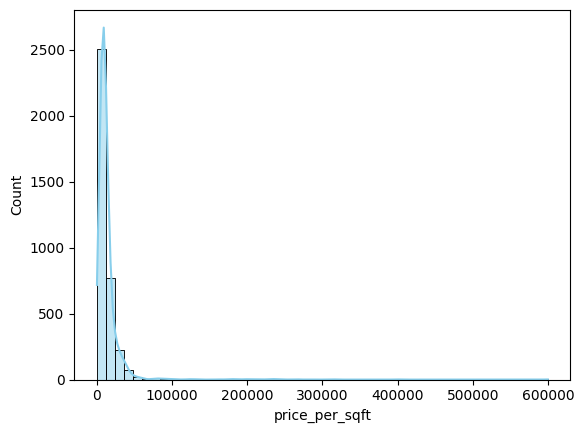

In [33]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)



Most properties have a price_per_sqft ranging between approximately ₹0 and ₹40,000. There is a significant concentration in the lower range, with a few properties having exceptionally high price_per_sqft.

<Axes: ylabel='price_per_sqft'>

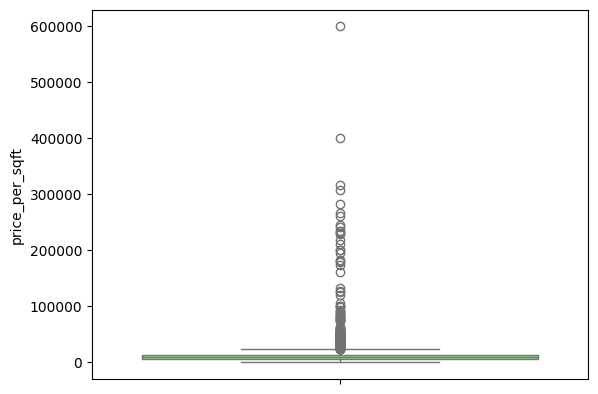

In [34]:
sns.boxplot(df['price_per_sqft'], color='lightgreen')


The box plot clearly shows several outliers, especially on the higher side. The interquartile range (IQR) is relatively compact, but there are many data points beyond the "whiskers" of the box plot, indicating potential outliers

---


Potential Outliers

Right Skewed

17 missing values

In [35]:
df['bedRoom'].isnull().sum()


np.int64(0)

<Axes: xlabel='bedRoom'>

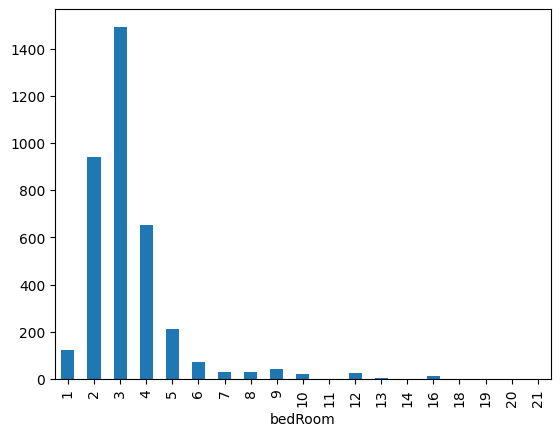

In [36]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')


<Axes: ylabel='proportion'>

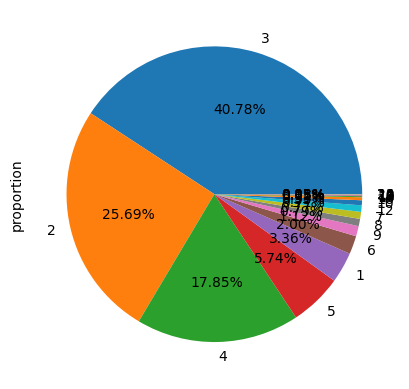

In [37]:
df['bedRoom'].value_counts(normalize=True).plot(kind='pie',autopct='%0.2f%%')


In [38]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

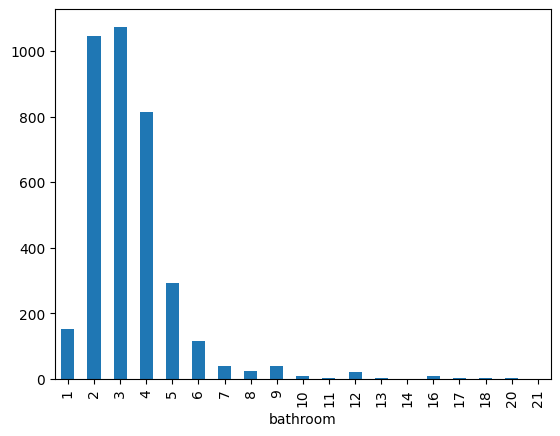

In [39]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

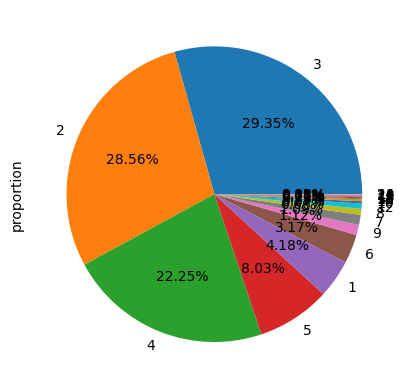

In [40]:
df['bathroom'].value_counts(normalize=True).plot(kind='pie',autopct='%0.2f%%')


<Axes: xlabel='balcony'>

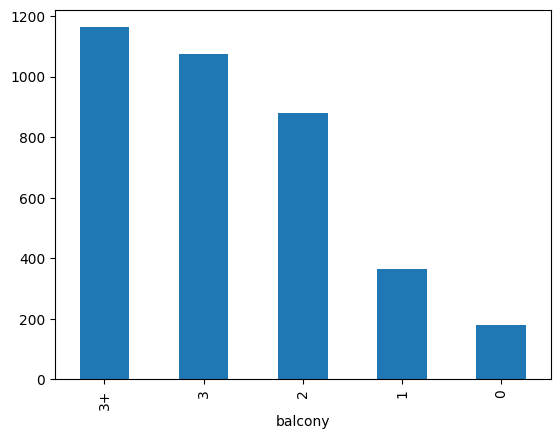

In [41]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

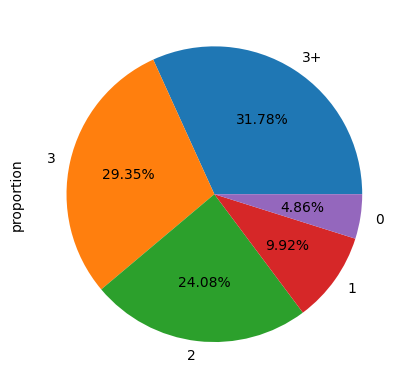

In [42]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [43]:
df['floorNum'].isnull().sum()

np.int64(0)

In [44]:
df['floorNum'].describe()


,floorNum
count,3659.000000
mean,6.799125
std,6.011865
min,0.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,51.000000


<Axes: xlabel='floorNum'>

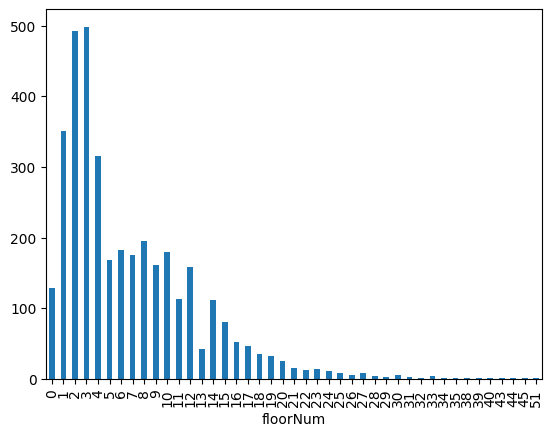

In [45]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')


<Axes: ylabel='floorNum'>

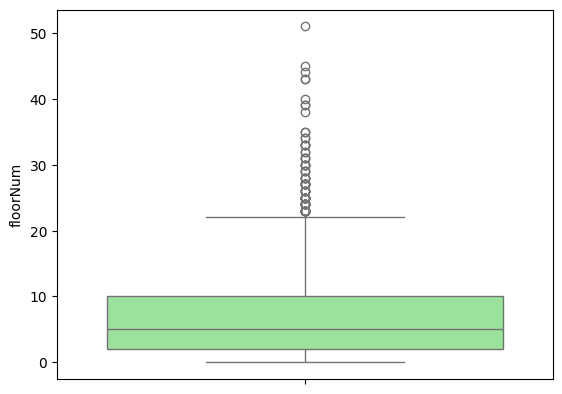

In [46]:
sns.boxplot(df['floorNum'], color='lightgreen')


The majority of the properties lie between the ground floor (0) and the 25th floor.

Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.

There are a few properties located at higher floors, but their frequency is much lower.

The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.

Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers

In [47]:
df['facing'].isnull().sum()

np.int64(1034)

In [48]:

df['facing'].fillna('NA',inplace=True)

/tmp/ipykernel_368/1746189610.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['facing'].fillna('NA',inplace=True)


In [49]:
df['facing'].value_counts()


,count
facing,
NA,1034
North-East,622
East,621
North,387
West,247
South,231
North-West,193
South-East,173
South-West,151


In [50]:
df['agePossession'].isnull().sum()


np.int64(0)

In [51]:
df['agePossession'].value_counts()


,count
agePossession,
Relatively New,1643
New Property,592
Moderately Old,557
Undefined,307
Old Property,297
Under Construction,263


In [52]:
df['super_built_up_area'].isnull().sum()


np.int64(1784)

In [53]:
df['super_built_up_area'].describe()


,super_built_up_area
count,1875.000000
mean,1925.237627
std,764.172177
min,89.000000
25%,1479.500000
50%,1828.000000
75%,2215.000000
max,10000.000000


<Axes: xlabel='super_built_up_area', ylabel='Count'>

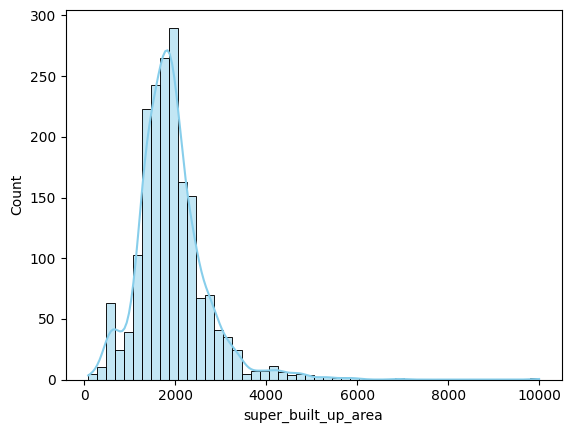

In [54]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: ylabel='super_built_up_area'>

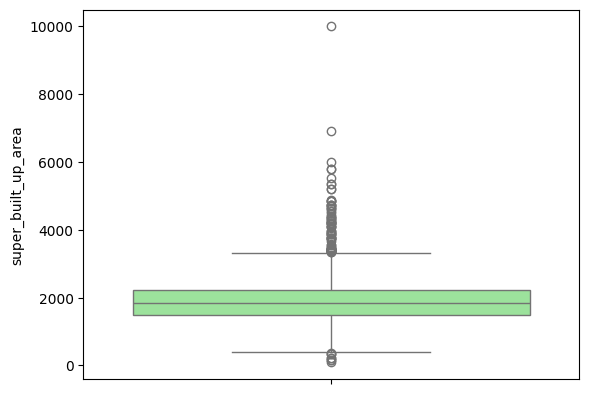

In [55]:
sns.boxplot(df['super_built_up_area'].dropna(), color='lightgreen')

Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.

There are a few properties with a significantly larger area, leading to a right-skewed distribution.

The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.

There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

You can use Pandas Profiling (now called ydata-profiling) to automatically generate an EDA report for your dataframe df.

In [56]:
!pip install ydata-profiling

In [57]:
import pandas as pd
from ydata_profiling import ProfileReport

profile=ProfileReport(df,title="Data Profiling Report")
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 23/23 [00:00<00:00, 25.65it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]